# VLST — Unified model comparison (`results.ipynb`)

Consolidates **best configurations** from `advanced.ipynb` and `tabpfn.ipynb` with the six **baseline** learners (LR, RF, XGB, CatBoost, LGBM, TabPFN).

| Protocol | Setting |
|----------|---------|
| **Split** | **70% train · 30% holdout test** (stratified, `RANDOM_STATE=42`) |
| **Training** | **Stratified K-fold OOF** on train for **every** model — each row predicted by a model that never saw it |
| **Test scores** | Mean of fold-model predictions on the frozen holdout (no leakage) |
| **Threshold** | Max Fβ on **OOF train** scores (TabPFN β=1.5; others β=2.0); grid `[0.01…0.99]` × 199 |
| **Blend weights** | SLSQP / Optuna / meta-LR fit on **OOF train** base predictions only |
| **Data** | `tabpfn.ipynb` minimal `load_raw()` · scaled view adds OHE |

**Model families**
- *Baselines*: `lr`, `rf`, `cat`, `xgb`, `lgb`, `tabpfn`
- *Advanced extras*: `rf_b`, `xgb_b`; SLSQP blends on OOF (`adv_*`)
- *TabPFN extras*: OOF-learned blends (`tabpfn_blend_*`, `tabpfn_stacking_lr`)

---

## Running on Kaggle

1. **New notebook** → enable **GPU T4** + **Internet**.
2. Add dataset [vlst-data](https://www.kaggle.com/datasets/amirmahdidaraei/vlst-data).
3. Secrets: `TABPFN_TOKEN` (+ optional `HF_TOKEN`).
4. **Run All** → outputs in `/kaggle/working/modeling_results/`.

In [1]:
import importlib.util as _il

_optional = []
for _pkg, _mod in [("optuna", "optuna"), ("tabpfn", "tabpfn")]:
    if _il.find_spec(_mod) is None:
        _optional.append(_pkg)
if _optional:
    %pip install -q --no-warn-conflicts {" ".join(_optional)}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.6/394.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.util as _il
import json
import os
import warnings
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.optimize import minimize as scipy_minimize
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11, "axes.labelsize": 10})

RANDOM_STATE = 42
TEST_SIZE = 0.30              # holdout test (stratified)
OOF_N_SPLITS = 5              # stratified OOF folds on train (all models)
OOF_N_SPLITS_TABPFN = 10      # TabPFN OOF folds (matches tabpfn.ipynb threshold tuning)
THRESHOLD_BETA = 2.0            # threshold objective for classical / advanced blends
TABPFN_THRESHOLD_BETA = 1.5     # tabpfn.ipynb §5
THRESHOLD_GRID_POINTS = 199     # tabpfn.ipynb select_threshold grid
BLEND_OPTUNA_TRIALS = 200

TARGET_COL = "Stent thrombosis"
DROP_FEATURES = ["Time since stent implantation"]   # leakage control (tabpfn.ipynb)
ID_COLS = ["NO.", "Name"]

ADV_MEMBERS = ["cat", "xgb", "rf", "rf_b", "xgb_b", "lgb", "lr"]
TABPFN_BLEND_MEMBERS = ["tabpfn", "lr", "rf", "cat", "xgb", "lgb"]

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
        Path(KAGGLE_RAW_CSV),
        Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
        Path("/kaggle/input/vlst-data/VLST.csv"),
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# GPU for boosters / TabPFN (matches advanced.ipynb + tabpfn.ipynb on Kaggle)
try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)

Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda


## 1. Load data — one cleaned row set, dual views (scaled + raw TabPFN)

In [3]:
def load_raw(raw_path):
    """Minimal TabPFN-native handling (tabpfn.ipynb): keep NaNs, code text columns, no scaling/OHE."""
    df = pd.read_csv(raw_path)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    y = df[TARGET_COL].astype(int).to_numpy()
    drop = [TARGET_COL] + [c for c in DROP_FEATURES if c in df.columns]
    X_df = df.drop(columns=drop)
    for c in X_df.columns:
        if X_df[c].dtype == object:
            coerced = pd.to_numeric(X_df[c].astype(str).str.strip(), errors="coerce")
            if coerced.notna().mean() >= 0.5:        # genuinely numeric (e.g. "21.00 ")
                X_df[c] = coerced
            else:                                     # categorical text -> integer codes (NOT one-hot)
                codes = X_df[c].astype("category").cat.codes.astype(float)
                X_df[c] = codes.where(codes >= 0, np.nan)
    return X_df.to_numpy(dtype=float), y, list(X_df.columns)


def load_dataframe(raw_path):
    """Same row set as load_raw, kept as a DataFrame for the scaled (OHE) view."""
    df = pd.read_csv(raw_path)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    df = df.drop(columns=[c for c in DROP_FEATURES if c in df.columns])
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype(int)
    return df


def _feature_columns(df):
    feature_cols = [c for c in df.columns if c != TARGET_COL]
    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
    binary_cols = [c for c in numeric_cols if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2]
    continuous_cols = [c for c in numeric_cols if c not in binary_cols]
    constant_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
    if constant_cols:
        feature_cols = [c for c in feature_cols if c not in constant_cols]
        binary_cols = [c for c in binary_cols if c not in constant_cols]
        continuous_cols = [c for c in continuous_cols if c not in constant_cols]
        cat_cols = [c for c in cat_cols if c not in constant_cols]
    return feature_cols, binary_cols, continuous_cols, cat_cols


def _build_preprocessor(binary_cols, continuous_cols, cat_cols):
    transformers = []
    if continuous_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), continuous_cols))
    if binary_cols:
        transformers.append(("bin", SimpleImputer(strategy="most_frequent"), binary_cols))
    if cat_cols:
        ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
        transformers.append(("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")), ("ohe", ohe)]), cat_cols))
    return ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)


def df_to_scaled(df):
    feature_cols, binary_cols, continuous_cols, cat_cols = _feature_columns(df)
    preprocessor = _build_preprocessor(binary_cols, continuous_cols, cat_cols)
    X_df = df[feature_cols].copy()
    X_enc = preprocessor.fit_transform(X_df)
    names = preprocessor.get_feature_names_out().tolist()
    scaler = StandardScaler()
    return scaler.fit_transform(X_enc).astype(np.float64), names


df = load_dataframe(RAW_PATH)
X_raw, y_all, feature_names_raw = load_raw(RAW_PATH)
assert np.array_equal(y_all, df[TARGET_COL].to_numpy())
X_all, feature_names_scaled = df_to_scaled(df)
assert len(y_all) == X_all.shape[0] == X_raw.shape[0]
print(f"Rows={len(y_all):,} | scaled features={X_all.shape[1]} | raw features={X_raw.shape[1]}")
print(f"Class balance: 0={(y_all==0).sum()} | 1={(y_all==1).sum()}")

Rows=5,185 | scaled features=185 | raw features=81
Class balance: 0=5093 | 1=92


In [4]:
# Index-based splits — identical rows in scaled & raw views
idx = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE,
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]
X_raw_train = X_raw[train_idx]
X_raw_test = X_raw[test_idx]

split_stats = pd.DataFrame([
    {"split": "train", "n": len(train_idx), "positives": int((y_train == 1).sum()), "rate": (y_train == 1).mean()},
    {"split": "test", "n": len(test_idx), "positives": int((y_test == 1).sum()), "rate": (y_test == 1).mean()},
])
display(split_stats)
assert abs(len(train_idx) / len(y_all) - (1.0 - TEST_SIZE)) < 0.02
assert abs(len(test_idx) / len(y_all) - TEST_SIZE) < 0.02
print(f"Test positives={int((y_test==1).sum())} (tabpfn.ipynb uses same 70/30 split)")

,split,n,positives,rate
0,train,3629,64,0.017636
1,test,1556,28,0.017995


Test positives=28 (tabpfn.ipynb uses same 70/30 split)


## 2. Helpers, metrics, and blend utilities

In [5]:
SCALE_POS_WEIGHT = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))


class CatBoostClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model_ = CatBoostClassifier(**kwargs)

    def get_params(self, deep=True):
        return dict(self.kwargs)

    def set_params(self, **params):
        self.kwargs.update(params)
        self.model_ = CatBoostClassifier(**self.kwargs)
        return self

    def fit(self, X, y, **fit_params):
        self.model_.fit(X, y, **fit_params)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def pos_proba(est, X):
    p = est.predict_proba(X)
    if hasattr(est, "classes_"):
        idx = list(est.classes_).index(1) if 1 in est.classes_ else 1
    else:
        idx = 1
    return np.asarray(p[:, idx], dtype=float)


def ranking_metrics(y, p):
    return {
        "pr_auc": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)),
    }


def threshold_max_fbeta(y, p, beta=THRESHOLD_BETA, grid=None):
    grid = np.linspace(0.01, 0.99, THRESHOLD_GRID_POINTS) if grid is None else grid
    best_t, best_v = 0.5, -1.0
    for t in grid:
        v = fbeta_score(y, (p >= t).astype(int), beta=beta, zero_division=0)
        if v > best_v:
            best_t, best_v = float(t), float(v)
    return best_t


def operational_metrics(y, p, threshold):
    pred = (p >= threshold).astype(int)
    return {
        **ranking_metrics(y, p),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        f"f{THRESHOLD_BETA:g}": float(fbeta_score(y, pred, beta=THRESHOLD_BETA, zero_division=0)),
        "accuracy": float(accuracy_score(y, pred)),
        "threshold": float(threshold),
    }


def _simplex(w, eps=1e-12):
    w = np.clip(np.asarray(w, dtype=float), 0.0, None)
    s = w.sum()
    return w / s if s > eps else np.full_like(w, 1.0 / len(w))


def learn_slsqp(P, y):
    n = P.shape[1]
    x0 = np.full(n, 1.0 / n)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    res = scipy_minimize(
        lambda w: -average_precision_score(y, P @ w),
        x0=x0, method="SLSQP", bounds=[(0.0, 1.0)] * n, constraints=cons,
        options={"maxiter": 300, "ftol": 1e-9},
    )
    return _simplex(res.x)


def blend_scores(P, w):
    return np.asarray(P, dtype=float) @ np.asarray(w, dtype=float)


def grid_max_pr(P, y, step=0.05):
    """Exhaustive 2-model simplex grid (advanced nocat-style)."""
    best_w, best_pr = None, -1.0
    for w0 in np.arange(0.0, 1.0 + step / 2, step):
        w = np.array([w0, 1.0 - w0])
        pr = average_precision_score(y, P @ w)
        if pr > best_pr:
            best_pr, best_w = pr, w
    return best_w, float(best_pr)


def threshold_policy(model_name):
    """All models: tune threshold on OOF train scores."""
    return "oof_train"


def _threshold_beta(model_name):
    if model_name == "tabpfn" or model_name.startswith("tabpfn_"):
        return TABPFN_THRESHOLD_BETA
    return THRESHOLD_BETA


def oof_train_test(factory, X_train, y_train, X_test, *, n_splits=OOF_N_SPLITS, seed=RANDOM_STATE):
    """OOF train predictions + fold-averaged test predictions (stacking-safe, no leakage)."""
    oof = np.zeros(len(y_train), dtype=float)
    test_mean = np.zeros(X_test.shape[0], dtype=float)
    fold_rows = []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (tr, va) in enumerate(skf.split(X_train, y_train), 1):
        m = factory()
        m.fit(X_train[tr], y_train[tr])
        p_va = pos_proba(m, X_train[va])
        oof[va] = p_va
        test_mean += pos_proba(m, X_test) / n_splits
        fold_rows.append({"fold": fold, **ranking_metrics(y_train[va], p_va)})
    return oof, test_mean, pd.DataFrame(fold_rows)


def nested_oof_linear(P, y, learn_weights_fn, *, n_splits=OOF_N_SPLITS, seed=RANDOM_STATE):
    """Honest nested OOF for linear blends: weights learned on outer-train only."""
    oof = np.zeros(len(y), dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in skf.split(P, y):
        w = learn_weights_fn(P[tr], y[tr])
        oof[va] = blend_scores(P[va], w)
    return oof


def nested_oof_meta_lr(P, y, *, n_splits=OOF_N_SPLITS, seed=RANDOM_STATE):
    """Honest nested OOF for stacking LR: fit meta on outer-train only."""
    oof = np.zeros(len(y), dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in skf.split(P, y):
        meta = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=seed)
        meta.fit(P[tr], y[tr])
        oof[va] = meta.predict_proba(P[va])[:, 1]
    return oof


## 3. Model factories — frozen best hyperparameters from source notebooks

In [6]:
from lightgbm import early_stopping as lgb_early_stopping

# --- advanced.ipynb §5 winners ---
def make_lr(seed=RANDOM_STATE):
    return LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=seed)


def make_rf(seed=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        class_weight="balanced_subsample", n_jobs=-1, random_state=seed,
    )


def make_rf_b(seed=RANDOM_STATE):
    m = make_rf(seed=137 + seed)
    m.set_params(max_samples=0.88)
    return m


def make_cat(seed=RANDOM_STATE):
    return CatBoostClassifierWrapper(
        depth=6, learning_rate=0.05, l2_leaf_reg=5.0, iterations=800,
        eval_metric="AUC", logging_level="Silent", auto_class_weights="Balanced",
        random_seed=seed, task_type=CATBOOST_TASK_TYPE,
    )


def make_xgb(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05, reg_lambda=2.0,
        subsample=0.9, colsample_bytree=0.9, objective="binary:logistic",
        eval_metric="aucpr", scale_pos_weight=SCALE_POS_WEIGHT, random_state=seed,
        device=XGB_DEVICE,
    )


def make_xgb_b(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05, reg_lambda=2.0,
        subsample=0.78, colsample_bytree=0.78, objective="binary:logistic",
        eval_metric="aucpr", scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=91 + seed, device=XGB_DEVICE,
    )


def make_lgb(seed=RANDOM_STATE):
    return LGBMClassifier(
        n_estimators=600, max_depth=8, num_leaves=31, learning_rate=0.05,
        class_weight="balanced", random_state=seed, verbosity=-1, device=LGB_DEVICE,
    )


SCALED_FACTORIES = {
    "lr": make_lr,
    "rf": make_rf,
    "rf_b": make_rf_b,
    "cat": make_cat,
    "xgb": make_xgb,
    "xgb_b": make_xgb_b,
    "lgb": make_lgb,
}

# --- tabpfn.ipynb §9 calibrated classical bases (for TabPFN-native raw matrix) ---
def _calibrate(est):
    return CalibratedClassifierCV(est, method="sigmoid", cv=3)


def make_lr_raw(seed=RANDOM_STATE):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(C=2.0, solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=seed)),
    ])
    return _calibrate(pipe)


def make_rf_raw(seed=RANDOM_STATE):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=seed)),
    ])
    return _calibrate(pipe)


def make_cat_raw(seed=RANDOM_STATE):
    base = CatBoostClassifier(depth=6, learning_rate=0.05, l2_leaf_reg=5.0, iterations=600, auto_class_weights="Balanced", verbose=0, random_state=seed)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("cat", base)]))


def make_xgb_raw(seed=RANDOM_STATE):
    base = XGBClassifier(max_depth=5, learning_rate=0.05, n_estimators=600, reg_lambda=2.0, scale_pos_weight=SCALE_POS_WEIGHT, eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=seed)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base)]))


def make_lgb_raw(seed=RANDOM_STATE):
    base = LGBMClassifier(max_depth=8, learning_rate=0.05, num_leaves=31, n_estimators=600, class_weight="balanced", n_jobs=-1, random_state=seed, verbosity=-1)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("lgb", base)]))


RAW_CLASSICAL_FACTORIES = {
    "lr": make_lr_raw,
    "rf": make_rf_raw,
    "cat": make_cat_raw,
    "xgb": make_xgb_raw,
    "lgb": make_lgb_raw,
}

TABPFN_AVAILABLE = False
make_tabpfn = None

def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn
    if is_kaggle_env:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        hf = secrets.get_secret("HF_TOKEN") or ""
        tabpfn = secrets.get_secret("NEW_TABPFN_TOKEN") or secrets.get_secret("TABPFN_TOKEN") or ""
        return hf, tabpfn
    return hf, tabpfn

try:
    import torch
    from tabpfn import TabPFNClassifier

    _tabpfn_device = "cuda" if torch.cuda.is_available() else "cpu"
    _hf_token, _tabpfn_token = _load_tabpfn_tokens()
    if _tabpfn_token:
        os.environ["TABPFN_TOKEN"] = _tabpfn_token
    if _hf_token:
        os.environ["HF_TOKEN"] = _hf_token

    def make_tabpfn(seed=RANDOM_STATE):
        return TabPFNClassifier(
            device=_tabpfn_device, n_estimators=-1, balance_probabilities=True,
            ignore_pretraining_limits=False, random_state=seed,
        )

    if _tabpfn_token:
        TABPFN_AVAILABLE = True
        print(f"TabPFN ready on {_tabpfn_device}")
    else:
        print("TABPFN_TOKEN not set — TabPFN models will be skipped.")
except Exception as exc:
    print("TabPFN unavailable:", exc)

OPTUNA_AVAILABLE = _il.find_spec("optuna") is not None
print("Optuna:", "yes" if OPTUNA_AVAILABLE else "no (SLSQP blends still run)")

TabPFN ready on cuda
Optuna: yes


## 4. OOF training — all base models

Stratified K-fold on **train only**. Each training row gets one out-of-fold score; holdout **test** scores are the mean of fold-model predictions (no leakage).

In [7]:
P_train_oof, P_test = {}, {}
cv_frames = []

for name, factory in SCALED_FACTORIES.items():
    oof, p_test, fold_df = oof_train_test(factory, X_train, y_train, X_test, n_splits=OOF_N_SPLITS)
    P_train_oof[name] = oof
    P_test[name] = p_test
    fold_df["model"] = name
    fold_df["family"] = "baseline" if name in {"lr", "rf", "cat", "xgb", "lgb"} else "advanced"
    cv_frames.append(fold_df)
    print(f"{name:6s} | OOF PR-AUC {average_precision_score(y_train, oof):.4f} | test PR-AUC {average_precision_score(y_test, p_test):.4f}")

if TABPFN_AVAILABLE:
    oof, p_test, fold_df = oof_train_test(
        make_tabpfn, X_raw_train, y_train, X_raw_test, n_splits=OOF_N_SPLITS_TABPFN,
    )
    P_train_oof["tabpfn"] = oof
    P_test["tabpfn"] = p_test
    fold_df["model"] = "tabpfn"
    fold_df["family"] = "baseline"
    cv_frames.append(fold_df)
    print(f"{'tabpfn':6s} | OOF PR-AUC {average_precision_score(y_train, oof):.4f} | test PR-AUC {average_precision_score(y_test, p_test):.4f}")

for name, factory in RAW_CLASSICAL_FACTORIES.items():
    key = f"{name}_raw"
    oof, p_test, fold_df = oof_train_test(factory, X_raw_train, y_train, X_raw_test, n_splits=OOF_N_SPLITS)
    P_train_oof[key] = oof
    P_test[key] = p_test
    fold_df["model"] = key
    fold_df["family"] = "tabpfn_base"
    cv_frames.append(fold_df)
    print(f"{key:10s} | OOF PR-AUC {average_precision_score(y_train, oof):.4f} | test PR-AUC {average_precision_score(y_test, p_test):.4f}")

cv_detail = pd.concat(cv_frames, ignore_index=True)
cv_summary = (
    cv_detail.groupby(["model", "family"], as_index=False)
    .agg(pr_auc_mean=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"), roc_auc_mean=("roc_auc", "mean"), roc_auc_std=("roc_auc", "std"))
    .assign(oof_pr_auc_train=lambda d: d["model"].map({m: average_precision_score(y_train, P_train_oof[m]) for m in P_train_oof}))
    .sort_values("oof_pr_auc_train", ascending=False)
)
display(cv_summary.round(4))
print(f"OOF folds: {OOF_N_SPLITS} (TabPFN: {OOF_N_SPLITS_TABPFN}) | Test positives={int((y_test==1).sum())}")

lr     | OOF PR-AUC 0.3012 | test PR-AUC 0.4721
rf     | OOF PR-AUC 0.4968 | test PR-AUC 0.5684
rf_b   | OOF PR-AUC 0.5289 | test PR-AUC 0.5650


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


cat    | OOF PR-AUC 0.6116 | test PR-AUC 0.6704
xgb    | OOF PR-AUC 0.6762 | test PR-AUC 0.6711
xgb_b  | OOF PR-AUC 0.6540 | test PR-AUC 0.6560


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


lgb    | OOF PR-AUC 0.6988 | test PR-AUC 0.6770


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

tabpfn | OOF PR-AUC 0.6015 | test PR-AUC 0.8126
lr_raw     | OOF PR-AUC 0.2575 | test PR-AUC 0.4498
rf_raw     | OOF PR-AUC 0.5445 | test PR-AUC 0.5980
cat_raw    | OOF PR-AUC 0.6727 | test PR-AUC 0.6491
xgb_raw    | OOF PR-AUC 0.6339 | test PR-AUC 0.6589
lgb_raw    | OOF PR-AUC 0.5778 | test PR-AUC 0.6414


,model,family,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,oof_pr_auc_train
2,lgb,baseline,0.7092,0.0997,0.9708,0.0214,0.6988
10,xgb,baseline,0.6877,0.0562,0.9728,0.0190,0.6762
1,cat_raw,tabpfn_base,0.6845,0.1286,0.9676,0.0201,0.6727
11,xgb_b,advanced,0.6603,0.0762,0.9703,0.0182,0.6540
12,xgb_raw,tabpfn_base,0.6483,0.1209,0.9661,0.0250,0.6339
0,cat,baseline,0.6459,0.0512,0.9705,0.0099,0.6116
9,tabpfn,baseline,0.6451,0.1842,0.9614,0.0420,0.6015
3,lgb_raw,tabpfn_base,0.6299,0.0770,0.9731,0.0130,0.5778
8,rf_raw,tabpfn_base,0.5698,0.0980,0.9624,0.0275,0.5445
7,rf_b,advanced,0.5574,0.0788,0.9565,0.0360,0.5289


OOF folds: 5 (TabPFN: 10) | Test positives=28


## 5. Ensemble blends (weights from OOF train)

All blend weights are learned on **OOF train** base predictions; test scores use fold-averaged base predictions.

In [8]:
# Base models trained via OOF in §4 — P_train_oof, P_test ready for blends.
print(f"OOF bases ready: {len(P_train_oof)} models | test positives={int((y_test==1).sum())}")

OOF bases ready: 13 models | test positives=28


In [9]:
blend_specs = {}
Poof = None

# --- advanced.ipynb-style blends (weights on OOF train) ---
adv4 = [m for m in ["cat", "xgb", "rf", "rf_b"] if m in P_train_oof]
P4_oof = np.column_stack([P_train_oof[m] for m in adv4])
P4_test = np.column_stack([P_test[m] for m in adv4])
w4 = learn_slsqp(P4_oof, y_train)
blend_specs["adv_4way_slsqp"] = {"members": adv4, "weights": w4, "P_oof": P4_oof, "P_test": P4_test, "family": "advanced"}

adv3 = [m for m in ["cat", "xgb", "rf"] if m in P_train_oof]
P3_oof = np.column_stack([P_train_oof[m] for m in adv3])
P3_test = np.column_stack([P_test[m] for m in adv3])
w3 = learn_slsqp(P3_oof, y_train)
blend_specs["adv_3way_slsqp"] = {"members": adv3, "weights": w3, "P_oof": P3_oof, "P_test": P3_test, "family": "advanced"}

adv7 = [m for m in ADV_MEMBERS if m in P_train_oof]
P7_oof = np.column_stack([P_train_oof[m] for m in adv7])
P7_test = np.column_stack([P_test[m] for m in adv7])
w7 = learn_slsqp(P7_oof, y_train)
blend_specs["adv_7way_slsqp"] = {"members": adv7, "weights": w7, "P_oof": P7_oof, "P_test": P7_test, "family": "advanced"}

nocat = [m for m in ["xgb", "rf"] if m in P_train_oof]
Pn_oof = np.column_stack([P_train_oof[m] for m in nocat])
Pn_test = np.column_stack([P_test[m] for m in nocat])
wn, _ = grid_max_pr(Pn_oof, y_train)
blend_specs["adv_nocat_grid_f2"] = {"members": nocat, "weights": wn, "P_oof": Pn_oof, "P_test": Pn_test, "family": "advanced"}

# --- tabpfn.ipynb-style blends (OOF weights) ---
if TABPFN_AVAILABLE:
    tab_members = ["tabpfn"] + [f"{m}_raw" for m in ["lr", "rf", "cat", "xgb", "lgb"]]
    tab_members = [m for m in tab_members if m in P_train_oof]
    Poof = np.column_stack([P_train_oof[m] for m in tab_members])
    Pt = np.column_stack([P_test[m] for m in tab_members])

    w_uni = np.full(len(tab_members), 1.0 / len(tab_members))
    blend_specs["tabpfn_blend_uniform"] = {"members": tab_members, "weights": w_uni, "P_oof": Poof, "P_test": Pt, "family": "tabpfn"}

    w_slsqp = learn_slsqp(Poof, y_train)
    blend_specs["tabpfn_blend_slsqp"] = {"members": tab_members, "weights": w_slsqp, "P_oof": Poof, "P_test": Pt, "family": "tabpfn"}

    meta_lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
    meta_lr.fit(Poof, y_train)
    blend_specs["tabpfn_stacking_lr"] = {
        "members": tab_members, "weights": None, "meta": meta_lr, "P_oof": Poof, "P_test": Pt, "family": "tabpfn",
    }

    if OPTUNA_AVAILABLE:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        def _optuna_objective(trial):
            raw = np.array([trial.suggest_float(f"w_{m}", 1e-3, 1.0) for m in tab_members])
            mask = np.array([trial.suggest_int(f"use_{m}", 0, 1) for m in tab_members], dtype=bool)
            if mask.sum() < 2:
                top = np.argsort(-raw)[:2]
                mask = np.zeros(len(tab_members), dtype=bool)
                mask[top] = True
            w = np.zeros(len(tab_members))
            w[mask] = _simplex(raw[mask])
            return average_precision_score(y_train, Poof @ w)

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(_optuna_objective, n_trials=BLEND_OPTUNA_TRIALS, show_progress_bar=False)
        raw = np.array([study.best_params[f"w_{m}"] for m in tab_members])
        mask = np.array([study.best_params[f"use_{m}"] for m in tab_members], dtype=bool)
        if mask.sum() < 2:
            mask[np.argsort(-raw)[:2]] = True
        w_opt = np.zeros(len(tab_members))
        w_opt[mask] = _simplex(raw[mask])
        blend_specs["tabpfn_blend_optuna"] = {"members": tab_members, "weights": w_opt, "P_oof": Poof, "P_test": Pt, "family": "tabpfn"}

for label, spec in blend_specs.items():
    if spec.get("meta") is not None:
        spec["scores_oof_train"] = nested_oof_meta_lr(spec["P_oof"], y_train)
        spec["scores_test"] = spec["meta"].predict_proba(spec["P_test"])[:, 1]
        wtxt = "meta_lr"
    else:
        if label == "tabpfn_blend_slsqp":
            spec["scores_oof_train"] = nested_oof_linear(spec["P_oof"], y_train, learn_slsqp)
        elif label == "tabpfn_blend_optuna" and OPTUNA_AVAILABLE:
            def _learn_optuna_nested(P_tr, y_tr):
                import optuna
                optuna.logging.set_verbosity(optuna.logging.WARNING)
                n = P_tr.shape[1]
                def _obj(trial):
                    raw = np.array([trial.suggest_float(f"w_{i}", 1e-3, 1.0) for i in range(n)])
                    mask = np.array([trial.suggest_int(f"use_{i}", 0, 1) for i in range(n)], dtype=bool)
                    if mask.sum() < 2:
                        top = np.argsort(-raw)[:2]
                        mask = np.zeros(n, dtype=bool)
                        mask[top] = True
                    w = np.zeros(n)
                    w[mask] = _simplex(raw[mask])
                    return average_precision_score(y_tr, P_tr @ w)
                study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
                study.optimize(_obj, n_trials=min(80, BLEND_OPTUNA_TRIALS), show_progress_bar=False)
                raw = np.array([study.best_params[f"w_{i}"] for i in range(n)])
                mask = np.array([study.best_params[f"use_{i}"] for i in range(n)], dtype=bool)
                if mask.sum() < 2:
                    mask[np.argsort(-raw)[:2]] = True
                w = np.zeros(n)
                w[mask] = _simplex(raw[mask])
                return w
            spec["scores_oof_train"] = nested_oof_linear(spec["P_oof"], y_train, _learn_optuna_nested)
        elif label.startswith("adv_"):
            if label == "adv_nocat_grid_f2":
                spec["scores_oof_train"] = nested_oof_linear(spec["P_oof"], y_train, lambda P, y: grid_max_pr(P, y)[0])
            else:
                spec["scores_oof_train"] = nested_oof_linear(spec["P_oof"], y_train, learn_slsqp)
        else:
            spec["scores_oof_train"] = blend_scores(spec["P_oof"], spec["weights"])
        spec["scores_test"] = blend_scores(spec["P_test"], spec["weights"])
        wtxt = np.round(spec["weights"], 3).tolist()
    print(f"{label:22s} | members={spec['members']} | weights={wtxt}")

adv_4way_slsqp         | members=['cat', 'xgb', 'rf', 'rf_b'] | weights=[0.25, 0.25, 0.25, 0.25]
adv_3way_slsqp         | members=['cat', 'xgb', 'rf'] | weights=[0.333, 0.333, 0.333]
adv_7way_slsqp         | members=['cat', 'xgb', 'rf', 'rf_b', 'xgb_b', 'lgb', 'lr'] | weights=[0.143, 0.143, 0.143, 0.143, 0.143, 0.143, 0.143]
adv_nocat_grid_f2      | members=['xgb', 'rf'] | weights=[1.0, 0.0]
tabpfn_blend_uniform   | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.167, 0.167, 0.167, 0.167, 0.167, 0.167]
tabpfn_blend_slsqp     | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.167, 0.167, 0.167, 0.167, 0.167, 0.167]
tabpfn_stacking_lr     | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=meta_lr
tabpfn_blend_optuna    | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.276, 0.0, 0.11, 0.614, 0.0, 0.0]


In [10]:
rows = []
model_thresholds = {}


def _tune_threshold(model, scores_oof_train):
    return threshold_max_fbeta(y_train, scores_oof_train, beta=_threshold_beta(model))


def _append_rows(model, family, scores_oof_train, scores_test):
    t = _tune_threshold(model, scores_oof_train)
    model_thresholds[model] = t
    for split, y_true, scores in (("oof_train", y_train, scores_oof_train), ("test", y_test, scores_test)):
        mets = operational_metrics(y_true, scores, t)
        rows.append({
            "model": model, "family": family, "split": split,
            "threshold_policy": threshold_policy(model), "threshold": t, **mets,
        })


baseline_names = ["lr", "rf", "cat", "xgb", "lgb"] + (["tabpfn"] if TABPFN_AVAILABLE else [])
for name in baseline_names + ["rf_b", "xgb_b"]:
    family = "baseline" if name in baseline_names else "advanced"
    _append_rows(name, family, P_train_oof[name], P_test[name])

for label, spec in blend_specs.items():
    _append_rows(label, spec["family"], spec["scores_oof_train"], spec["scores_test"])

results = pd.DataFrame(rows)
results = results.merge(cv_summary[["model", "pr_auc_mean", "pr_auc_std", "oof_pr_auc_train"]], on="model", how="left")

test_leaderboard = (
    results[results["split"] == "test"]
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)
display(test_leaderboard[[
    "model", "family", "pr_auc", "roc_auc", "f1", "recall", "precision",
    "threshold", "threshold_policy", "pr_auc_mean", "oof_pr_auc_train",
]].round(4))

results.to_csv(RESULT_DIR / "results_metrics.csv", index=False)
cv_detail.to_csv(RESULT_DIR / "results_cv_folds.csv", index=False)
test_leaderboard.to_csv(RESULT_DIR / "results_test_leaderboard.csv", index=False)
print("Saved CSVs to", RESULT_DIR)
if TABPFN_AVAILABLE and "tabpfn" in P_test:
    print(f"Standalone tabpfn test PR-AUC={average_precision_score(y_test, P_test['tabpfn']):.4f} (tabpfn.ipynb target ~0.82)")

,model,family,pr_auc,roc_auc,f1,recall,precision,threshold,threshold_policy,pr_auc_mean,oof_pr_auc_train
0,tabpfn,baseline,0.8126,0.9921,0.7200,0.6429,0.8182,0.8811,oof_train,0.6451,0.6015
1,tabpfn_stacking_lr,tabpfn,0.7920,0.9914,0.7018,0.7143,0.6897,0.8811,oof_train,NaN,NaN
2,tabpfn_blend_optuna,tabpfn,0.7868,0.9913,0.6923,0.6429,0.7500,0.2872,oof_train,NaN,NaN
3,tabpfn_blend_uniform,tabpfn,0.7827,0.9910,0.6885,0.7500,0.6364,0.1832,oof_train,NaN,NaN
4,tabpfn_blend_slsqp,tabpfn,0.7827,0.9910,0.6885,0.7500,0.6364,0.1832,oof_train,NaN,NaN
5,adv_7way_slsqp,advanced,0.6886,0.9597,0.6296,0.6071,0.6538,0.2030,oof_train,NaN,NaN
6,adv_3way_slsqp,advanced,0.6811,0.9624,0.5556,0.7143,0.4545,0.0743,oof_train,NaN,NaN
7,lgb,baseline,0.6770,0.9649,0.6296,0.6071,0.6538,0.0100,oof_train,0.7092,0.6988
8,adv_4way_slsqp,advanced,0.6743,0.9628,0.5882,0.7143,0.5000,0.0941,oof_train,NaN,NaN
9,xgb,baseline,0.6711,0.9624,0.5143,0.6429,0.4286,0.0496,oof_train,0.6877,0.6762


Saved CSVs to /kaggle/working/modeling_results
Standalone tabpfn test PR-AUC=0.8126 (tabpfn.ipynb target ~0.82)


## 6. Figure panels — CV · test ranking · curves · operations

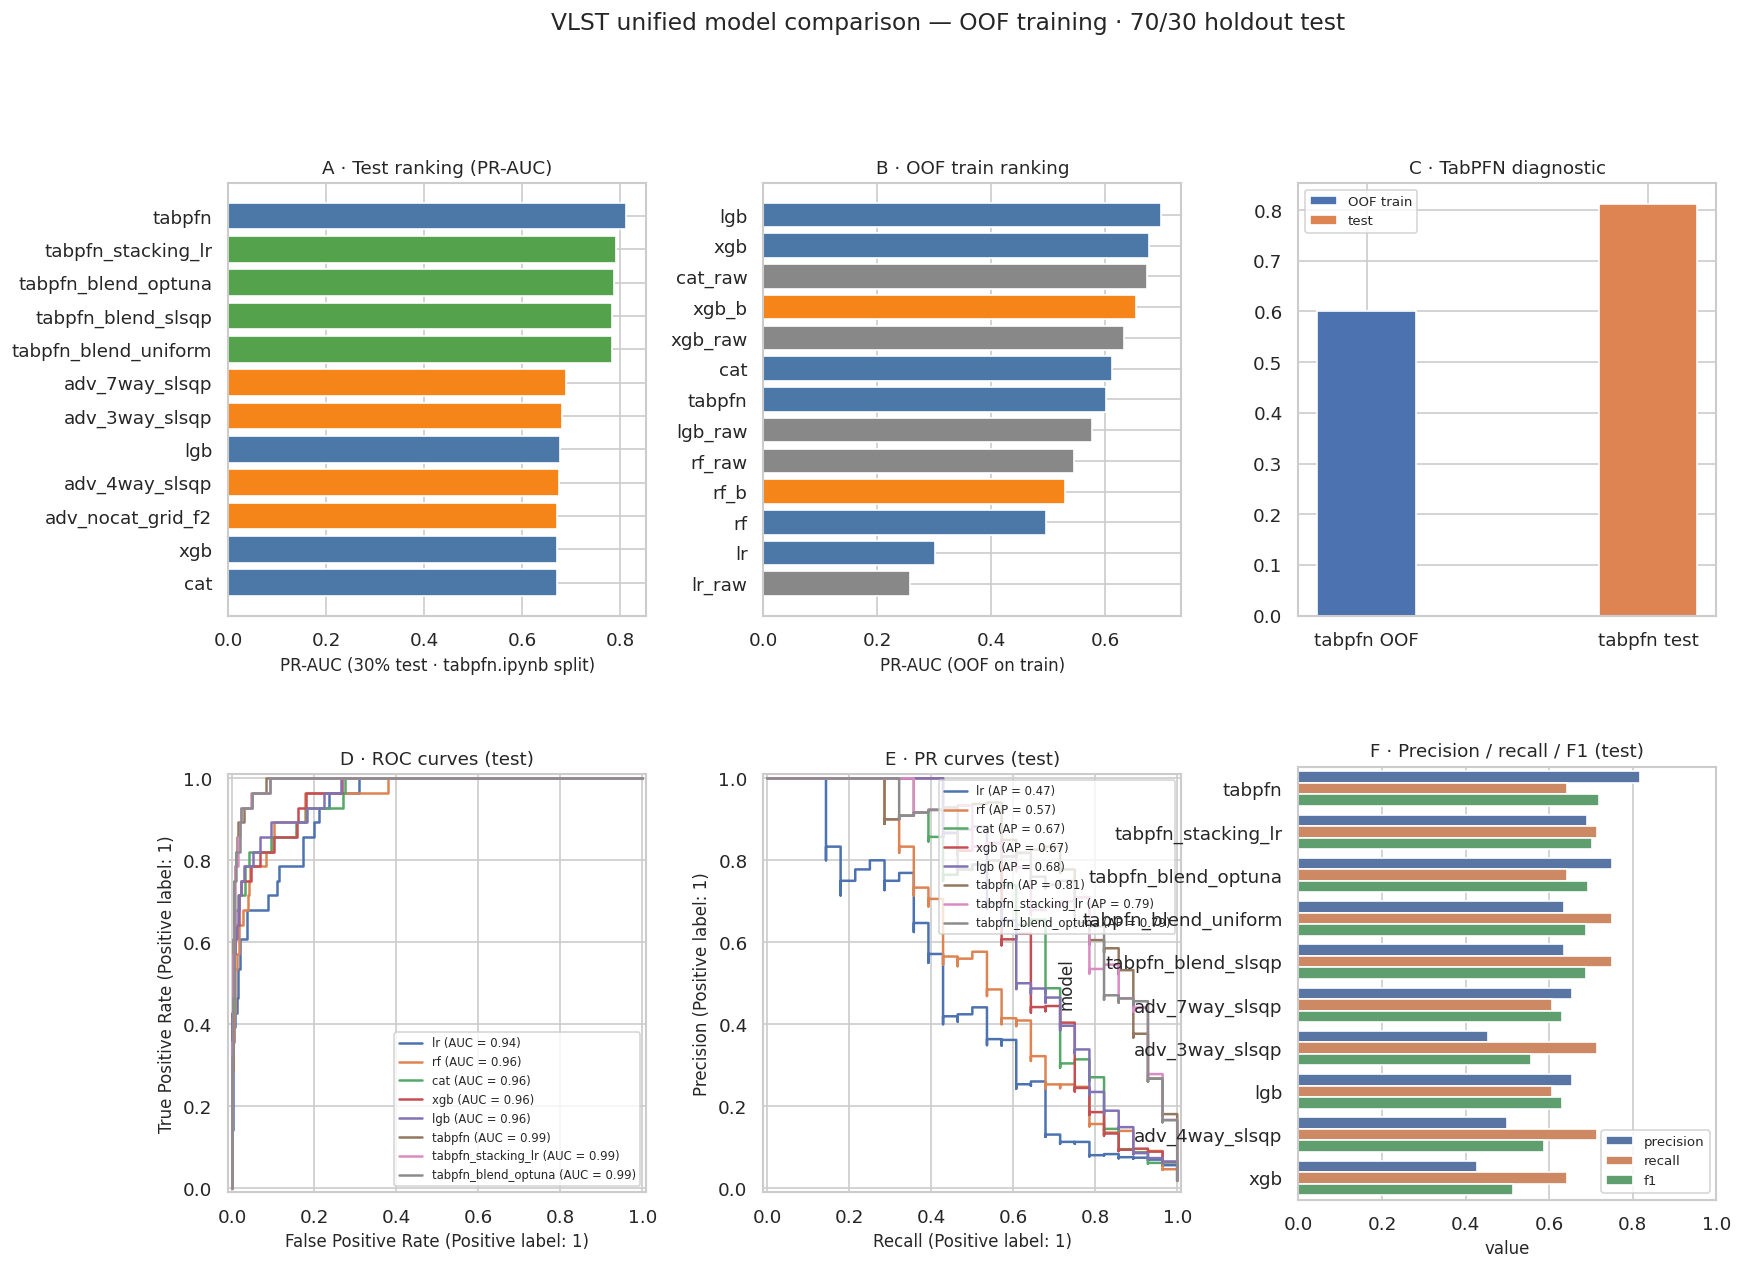

Saved figure: /kaggle/working/modeling_results/results_comparison_panels.png


In [11]:
palette = {"baseline": "#4C78A8", "advanced": "#F58518", "tabpfn": "#54A24B"}
top_models = test_leaderboard.head(10)["model"].tolist()
baseline_keep = [m for m in (["lr", "rf", "cat", "xgb", "lgb"] + (["tabpfn"] if TABPFN_AVAILABLE else []))]
curve_models = list(dict.fromkeys(baseline_keep + [m for m in top_models if m not in baseline_keep]))[:8]

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

# Panel A — Test PR-AUC (primary ranking)
ax_a = fig.add_subplot(gs[0, 0])
plot_test = test_leaderboard.sort_values("pr_auc", ascending=True).tail(12)
colors_a = [palette.get(f, "#888") for f in plot_test["family"]]
ax_a.barh(plot_test["model"], plot_test["pr_auc"], color=colors_a)
ax_a.set_xlabel("PR-AUC (30% test · tabpfn.ipynb split)")
ax_a.set_title("A · Test ranking (PR-AUC)")

# Panel B — OOF train PR-AUC (all models)
ax_b = fig.add_subplot(gs[0, 1])
plot_oof = cv_summary.sort_values("oof_pr_auc_train", ascending=True)
colors_b = [palette.get(f, "#888") for f in plot_oof["family"]]
ax_b.barh(plot_oof["model"], plot_oof["oof_pr_auc_train"], color=colors_b)
ax_b.set_xlabel("PR-AUC (OOF on train)")
ax_b.set_title("B · OOF train ranking")

# Panel C — OOF vs test (TabPFN diagnostic)
ax_c = fig.add_subplot(gs[0, 2])
if TABPFN_AVAILABLE and "tabpfn" in P_train_oof:
    ax_c.bar([0], [average_precision_score(y_train, P_train_oof["tabpfn"])], width=0.35, label="OOF train")
    ax_c.bar([1], [float(test_leaderboard.loc[test_leaderboard["model"]=="tabpfn", "pr_auc"].iloc[0])], width=0.35, label="test")
    ax_c.set_xticks([0, 1]); ax_c.set_xticklabels(["tabpfn OOF", "tabpfn test"])
    ax_c.legend(fontsize=8)
else:
    ax_c.text(0.5, 0.5, "TabPFN N/A", ha="center", va="center")
ax_c.set_title("C · TabPFN diagnostic")

# Panel D — ROC curves on test
ax_d = fig.add_subplot(gs[1, 0])
for name in curve_models:
    if name in blend_specs:
        scores = blend_specs[name]["scores_test"]
    else:
        scores = P_test[name]
    RocCurveDisplay.from_predictions(y_test, scores, ax=ax_d, name=name)
ax_d.set_title("D · ROC curves (test)")
ax_d.legend(fontsize=7, loc="lower right")

# Panel E — PR curves on test
ax_e = fig.add_subplot(gs[1, 1])
for name in curve_models:
    if name in blend_specs:
        scores = blend_specs[name]["scores_test"]
    else:
        scores = P_test[name]
    PrecisionRecallDisplay.from_predictions(y_test, scores, ax=ax_e, name=name)
ax_e.set_title("E · PR curves (test)")
ax_e.legend(fontsize=7, loc="upper right")

# Panel F — Operational metrics at tuned threshold (test, top 10)
ax_f = fig.add_subplot(gs[1, 2])
ops = test_leaderboard.head(10).melt(
    id_vars=["model", "family"], value_vars=["precision", "recall", "f1"], var_name="metric", value_name="value"
)
sns.barplot(data=ops, y="model", x="value", hue="metric", ax=ax_f)
ax_f.set_xlim(0, 1)
ax_f.set_title("F · Precision / recall / F1 (test)")
ax_f.legend(fontsize=8, loc="lower right")

fig.suptitle("VLST unified model comparison — OOF training · 70/30 holdout test", fontsize=14, y=1.01)
fig.savefig(RESULT_DIR / "results_comparison_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", RESULT_DIR / "results_comparison_panels.png")

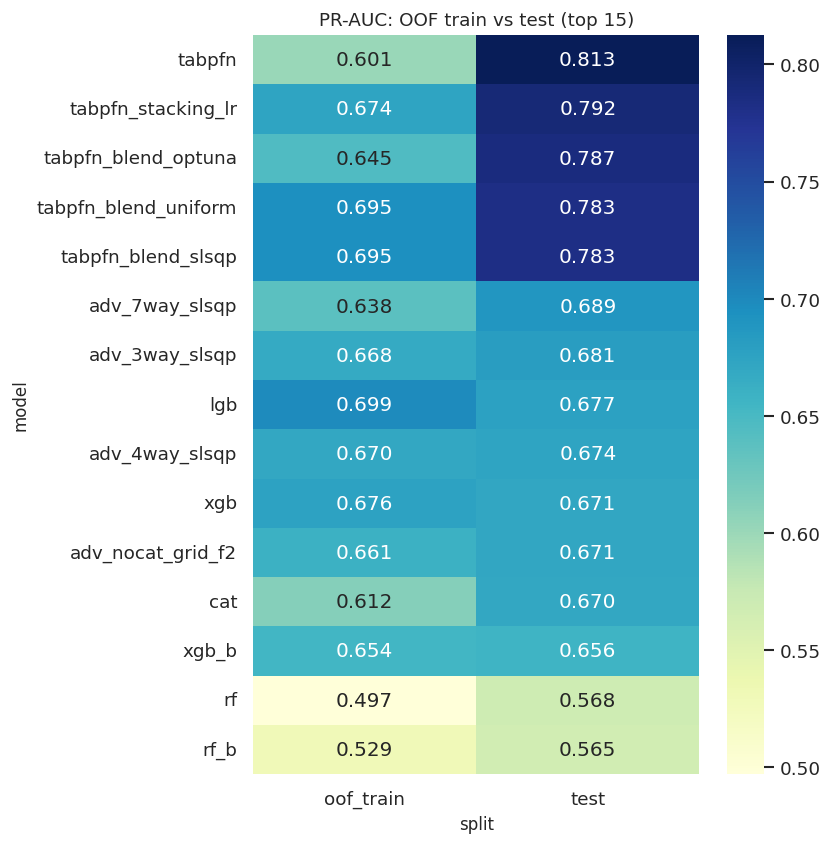

{
  "split": {
    "train": 0.7,
    "test": 0.3
  },
  "oof_n_splits": 5,
  "oof_n_splits_tabpfn": 10,
  "random_state": 42,
  "n_train": 3629,
  "n_test": 1556,
  "test_positives": 28,
  "tabpfn_ran": true,
  "optuna_ran": true,
  "tabpfn_test_pr_auc": 0.8125643010654924,
  "tabpfn_oof_pr_auc_train": 0.6014793672670014,
  "top_test_model": "tabpfn",
  "top_test_pr_auc": 0.8125643010654924
}


In [12]:
# Supplementary heatmap — all splits × key metrics
heat_metrics = ["pr_auc", "roc_auc", "f1", "recall", "precision"]
heat = results.pivot_table(index="model", columns="split", values="pr_auc")
heat = heat.loc[test_leaderboard["model"].head(15)]

fig2, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("PR-AUC: OOF train vs test (top 15)")
fig2.savefig(RESULT_DIR / "results_pr_auc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

manifest = {
    "split": {"train": 1.0 - TEST_SIZE, "test": TEST_SIZE},
    "oof_n_splits": OOF_N_SPLITS,
    "oof_n_splits_tabpfn": OOF_N_SPLITS_TABPFN,
    "random_state": RANDOM_STATE,
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "test_positives": int((y_test == 1).sum()),
    "tabpfn_ran": TABPFN_AVAILABLE,
    "optuna_ran": OPTUNA_AVAILABLE,
    "tabpfn_test_pr_auc": (
        float(test_leaderboard.loc[test_leaderboard["model"] == "tabpfn", "pr_auc"].iloc[0])
        if TABPFN_AVAILABLE and "tabpfn" in test_leaderboard["model"].values else None
    ),
    "tabpfn_oof_pr_auc_train": (
        float(average_precision_score(y_train, P_train_oof["tabpfn"]))
        if TABPFN_AVAILABLE and "tabpfn" in P_train_oof else None
    ),
    "top_test_model": test_leaderboard.iloc[0]["model"],
    "top_test_pr_auc": float(test_leaderboard.iloc[0]["pr_auc"]),
}
with open(RESULT_DIR / "results_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))

## 8. Fair primary comparison — Repeated Stratified Holdout (Monte-Carlo CV)

The single-run OOF metrics above **systematically underestimate TabPFN**: OOF shrinks its in-context "prompt" to ~80% of the training data, while the final test prediction gets 100%. Tree models are almost insensitive to that difference; TabPFN is not.

For the paper-ready comparison every model is evaluated under an **identical context budget**:

**Protocol**
- `StratifiedShuffleSplit` — `N_REPEATS=10` repeats × **80% train / 20% holdout** stratified on the target.
- Toggle `USE_SCALED_OHE` (default **off**) — when off, only the raw-feature path (`tabpfn.ipynb` style) and TabPFN are evaluated; when on, the scaled-OHE classical models and their `adv_*` blends are added.
- Per repeat, for every base model (`lr, rf, cat, xgb, lgb, tabpfn` and optionally `*_scaled`):
  1. Fit on **full 80% train** and score the 20% holdout → this is the standalone metric.
  2. Also generate inner `INNER_OOF_SPLITS`-fold OOF on the train slice — used **only** to (a) fit blend/meta weights honestly and (b) tune the decision threshold.
- Blends (`adv_*`, `tabpfn_blend_*`, `tabpfn_stacking_lr`) use inner OOF for weight/meta learning, then apply those weights to the full-train holdout predictions.
- Threshold policy: once max F1 on inner OOF + once max F2 on inner OOF (both reported side by side).
- Aggregate across repeats: **mean ± std** and **95% percentile CI** for PR-AUC, ROC-AUC, F1, F2, precision, recall.
- **Paired Wilcoxon signed-rank test** on per-repeat PR-AUC of every model vs `tabpfn`.

**Reported artefacts**
- `results_repeated_holdout_raw.csv` — per-repeat per-model metrics.
- `results_repeated_holdout_leaderboard.csv` — aggregated leaderboard with CIs and p-values.
- `results_repeated_holdout_boxplots.png` — 3-panel distribution across repeats: PR-AUC, F1 @ max-F1 threshold, F2 @ max-F2 threshold.

*Note on thresholds for blends*: the threshold is tuned on the same inner OOF used to fit blend weights, which is mildly optimistic for threshold-dependent metrics (F1/F2/precision/recall). PR-AUC and ROC-AUC — the ranking metrics used for the primary comparison — are threshold-free and unaffected.

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

USE_SCALED_OHE = False   # default OFF -> raw-feature path only (tabpfn.ipynb style)
N_REPEATS = 10
HOLDOUT_FRAC = 0.20
INNER_OOF_SPLITS = 5
THRESHOLD_BETAS = (1.0, 2.0)


def _fit_full_and_predict(factory, X_tr, y_tr, X_ho):
    m = factory()
    m.fit(X_tr, y_tr)
    return pos_proba(m, X_ho)


def _score_model(y_tr, y_ho, p_oof, p_ho, beta):
    t = threshold_max_fbeta(y_tr, p_oof, beta=beta)
    return {"threshold_beta": float(beta), **operational_metrics(y_ho, p_ho, t)}


def _run_repeat(train_idx, ho_idx, repeat_seed):
    Xs_tr, Xs_ho = X_all[train_idx], X_all[ho_idx]
    Xr_tr, Xr_ho = X_raw[train_idx], X_raw[ho_idx]
    y_tr, y_ho = y_all[train_idx], y_all[ho_idx]

    P_oof, P_ho, family = {}, {}, {}

    if USE_SCALED_OHE:
        for name, fac in SCALED_FACTORIES.items():
            key = f"{name}_scaled"
            oof, _, _ = oof_train_test(fac, Xs_tr, y_tr, Xs_ho, n_splits=INNER_OOF_SPLITS, seed=repeat_seed)
            P_oof[key] = oof
            P_ho[key] = _fit_full_and_predict(fac, Xs_tr, y_tr, Xs_ho)
            family[key] = "scaled"

    if TABPFN_AVAILABLE:
        oof, _, _ = oof_train_test(make_tabpfn, Xr_tr, y_tr, Xr_ho,
                                   n_splits=INNER_OOF_SPLITS, seed=repeat_seed)
        P_oof["tabpfn"] = oof
        P_ho["tabpfn"] = _fit_full_and_predict(make_tabpfn, Xr_tr, y_tr, Xr_ho)
        family["tabpfn"] = "tabpfn"

    for name, fac in RAW_CLASSICAL_FACTORIES.items():
        oof, _, _ = oof_train_test(fac, Xr_tr, y_tr, Xr_ho, n_splits=INNER_OOF_SPLITS, seed=repeat_seed)
        P_oof[name] = oof
        P_ho[name] = _fit_full_and_predict(fac, Xr_tr, y_tr, Xr_ho)
        family[name] = "baseline"

    blend_oof, blend_ho, blend_family = {}, {}, {}

    def _add_linear_blend(label, members, weights, fam):
        Po = np.column_stack([P_oof[m] for m in members])
        Ph = np.column_stack([P_ho[m] for m in members])
        blend_oof[label] = Po @ weights
        blend_ho[label] = Ph @ weights
        blend_family[label] = fam

    def _slsqp_blend(label, members, fam):
        members = [m for m in members if m in P_oof]
        if len(members) < 2:
            return
        Po = np.column_stack([P_oof[m] for m in members])
        w = learn_slsqp(Po, y_tr)
        _add_linear_blend(label, members, w, fam)

    if USE_SCALED_OHE:
        _slsqp_blend("adv_4way_slsqp", [f"{m}_scaled" for m in ["cat", "xgb", "rf", "rf_b"]], "advanced")
        _slsqp_blend("adv_3way_slsqp", [f"{m}_scaled" for m in ["cat", "xgb", "rf"]], "advanced")
        _slsqp_blend("adv_7way_slsqp", [f"{m}_scaled" for m in ADV_MEMBERS], "advanced")

        nocat = [f"{m}_scaled" for m in ["xgb", "rf"] if f"{m}_scaled" in P_oof]
        if len(nocat) == 2:
            Po = np.column_stack([P_oof[m] for m in nocat])
            w, _ = grid_max_pr(Po, y_tr)
            _add_linear_blend("adv_nocat_grid_f2", nocat, w, "advanced")

    if TABPFN_AVAILABLE and "tabpfn" in P_oof:
        tab_members = ["tabpfn"] + ["lr", "rf", "cat", "xgb", "lgb"]
        tab_members = [m for m in tab_members if m in P_oof]
        Po = np.column_stack([P_oof[m] for m in tab_members])
        Ph = np.column_stack([P_ho[m] for m in tab_members])

        w_uni = np.full(len(tab_members), 1.0 / len(tab_members))
        _add_linear_blend("tabpfn_blend_uniform", tab_members, w_uni, "tabpfn")

        w_slsqp = learn_slsqp(Po, y_tr)
        _add_linear_blend("tabpfn_blend_slsqp", tab_members, w_slsqp, "tabpfn")

        meta = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=repeat_seed)
        meta.fit(Po, y_tr)
        blend_oof["tabpfn_stacking_lr"] = meta.predict_proba(Po)[:, 1]
        blend_ho["tabpfn_stacking_lr"] = meta.predict_proba(Ph)[:, 1]
        blend_family["tabpfn_stacking_lr"] = "tabpfn"

        if OPTUNA_AVAILABLE:
            import optuna
            optuna.logging.set_verbosity(optuna.logging.WARNING)

            def _obj(trial):
                raw = np.array([trial.suggest_float(f"w_{i}", 1e-3, 1.0) for i in range(len(tab_members))])
                mask = np.array([trial.suggest_int(f"use_{i}", 0, 1) for i in range(len(tab_members))], dtype=bool)
                if mask.sum() < 2:
                    top = np.argsort(-raw)[:2]
                    mask = np.zeros(len(tab_members), dtype=bool)
                    mask[top] = True
                w = np.zeros(len(tab_members))
                w[mask] = _simplex(raw[mask])
                return average_precision_score(y_tr, Po @ w)

            study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=repeat_seed))
            study.optimize(_obj, n_trials=min(80, BLEND_OPTUNA_TRIALS), show_progress_bar=False)
            raw = np.array([study.best_params[f"w_{i}"] for i in range(len(tab_members))])
            mask = np.array([study.best_params[f"use_{i}"] for i in range(len(tab_members))], dtype=bool)
            if mask.sum() < 2:
                top = np.argsort(-raw)[:2]
                mask = np.zeros(len(tab_members), dtype=bool)
                mask[top] = True
            w_opt = np.zeros(len(tab_members))
            w_opt[mask] = _simplex(raw[mask])
            _add_linear_blend("tabpfn_blend_optuna", tab_members, w_opt, "tabpfn")

    rows = []
    for name in P_ho:
        for beta in THRESHOLD_BETAS:
            rows.append({"model": name, "family": family[name],
                         **_score_model(y_tr, y_ho, P_oof[name], P_ho[name], beta)})
    for label in blend_ho:
        for beta in THRESHOLD_BETAS:
            rows.append({"model": label, "family": blend_family[label],
                         **_score_model(y_tr, y_ho, blend_oof[label], blend_ho[label], beta)})
    return rows


sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
repeat_records = []
for rep, (tr, ho) in enumerate(sss.split(np.arange(len(y_all)), y_all), 1):
    print(f"[repeat {rep:2d}/{N_REPEATS}] train={len(tr)} holdout={len(ho)} "
          f"holdout_pos={int(y_all[ho].sum())}/{len(ho)}")
    seed = RANDOM_STATE + rep
    for row in _run_repeat(tr, ho, seed):
        row["repeat"] = rep
        repeat_records.append(row)

repeat_df = pd.DataFrame(repeat_records)
repeat_df.to_csv(RESULT_DIR / "results_repeated_holdout_raw.csv", index=False)
print(f"\nSaved {len(repeat_df)} rows to {RESULT_DIR / 'results_repeated_holdout_raw.csv'}")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(repeat_df)

[repeat  1/10] train=4666 holdout=519 holdout_pos=9/519


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[repeat  2/10] train=4666 holdout=519 holdout_pos=9/519


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[repeat  3/10] train=4666 holdout=519 holdout_pos=9/519


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[repeat 10/10] train=4666 holdout=519 holdout_pos=9/519


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



Saved 210 rows to /kaggle/working/modeling_results/results_repeated_holdout_raw.csv


,model,family,pr_auc,roc_auc,precision,recall,f1,f2,accuracy,threshold,repeat
0,lr,baseline,0.471448,0.922658,0.294118,0.555556,0.384615,0.471698,0.969171,0.851414,1
1,rf,baseline,0.433462,0.942484,0.294118,0.555556,0.384615,0.471698,0.969171,0.148586,1
2,rf_b,baseline,0.396168,0.950763,0.272727,0.666667,0.387097,0.517241,0.963391,0.133737,1
3,cat,baseline,0.566568,0.971242,0.357143,0.555556,0.434783,0.500000,0.974952,0.094141,1
4,xgb,baseline,0.605756,0.985403,0.444444,0.444444,0.444444,0.444444,0.980732,0.128788,1


In [14]:
from scipy.stats import wilcoxon

_METRICS_TO_AGG = ["pr_auc", "roc_auc", "f1", "f2", "precision", "recall", "accuracy", "threshold"]

def _aggregate(df, metrics=_METRICS_TO_AGG):
    rows = []
    for (m, fam, beta), g in df.groupby(["model", "family", "threshold_beta"]):
        row = {"model": m, "family": fam, "threshold_beta": float(beta), "n_repeats": len(g)}
        for metric in metrics:
            if metric not in g.columns:
                continue
            vals = g[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = float(np.mean(vals))
            row[f"{metric}_std"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            row[f"{metric}_p2p5"] = float(np.percentile(vals, 2.5))
            row[f"{metric}_p97p5"] = float(np.percentile(vals, 97.5))
        rows.append(row)
    return (pd.DataFrame(rows)
              .sort_values(["pr_auc_mean", "threshold_beta"], ascending=[False, True])
              .reset_index(drop=True))


agg = _aggregate(repeat_df)

ref = "tabpfn"
if ref in repeat_df["model"].unique():
    p_values, deltas = {}, {}
    for beta in sorted(repeat_df["threshold_beta"].unique()):
        ref_scores = (repeat_df[(repeat_df["model"] == ref) & (repeat_df["threshold_beta"] == beta)]
                      .set_index("repeat")["pr_auc"])
        for m in agg["model"].unique():
            s = (repeat_df[(repeat_df["model"] == m) & (repeat_df["threshold_beta"] == beta)]
                 .set_index("repeat")["pr_auc"])
            common = ref_scores.index.intersection(s.index)
            key = (m, float(beta))
            if m == ref or len(common) < 3:
                p_values[key] = np.nan
                deltas[key] = 0.0 if m == ref else np.nan
            else:
                diff = s.loc[common].to_numpy() - ref_scores.loc[common].to_numpy()
                deltas[key] = float(np.mean(diff))
                try:
                    if np.allclose(diff, 0):
                        p_values[key] = 1.0
                    else:
                        _, p = wilcoxon(diff, zero_method="wilcox", alternative="two-sided")
                        p_values[key] = float(p)
                except ValueError:
                    p_values[key] = np.nan
    agg["pr_auc_delta_vs_tabpfn"] = agg.apply(lambda r: deltas.get((r["model"], r["threshold_beta"]), np.nan), axis=1)
    agg["wilcoxon_p_vs_tabpfn"] = agg.apply(lambda r: p_values.get((r["model"], r["threshold_beta"]), np.nan), axis=1)

display_cols = [
    "model", "family", "threshold_beta", "n_repeats",
    "pr_auc_mean", "pr_auc_std", "pr_auc_p2p5", "pr_auc_p97p5",
    "roc_auc_mean", "f1_mean", "f2_mean", "precision_mean", "recall_mean",
    "threshold_mean",
]
if "wilcoxon_p_vs_tabpfn" in agg.columns:
    display_cols += ["pr_auc_delta_vs_tabpfn", "wilcoxon_p_vs_tabpfn"]

leaderboard = agg[display_cols].round({c: 4 for c in display_cols if c not in {"model", "family", "threshold_beta", "n_repeats"}})
print(f"Leaderboard across {N_REPEATS} stratified {int((1-HOLDOUT_FRAC)*100)}/{int(HOLDOUT_FRAC*100)} holdouts | scaled_ohe={USE_SCALED_OHE} | thresholds={{max-F1, max-F2}}:")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(leaderboard)

agg.to_csv(RESULT_DIR / "results_repeated_holdout_leaderboard.csv", index=False)
print(f"\nSaved leaderboard to {RESULT_DIR / 'results_repeated_holdout_leaderboard.csv'}")

Leaderboard across 10 stratified 90/10 holdouts:


,model,family,n_repeats,pr_auc_mean,pr_auc_std,pr_auc_p2p5,pr_auc_p97p5,roc_auc_mean,f1_mean,f2_mean,precision_mean,recall_mean,threshold_mean,pr_auc_delta_vs_tabpfn,wilcoxon_p_vs_tabpfn
0,tabpfn_blend_optuna,tabpfn,10,0.7206,0.1105,0.5127,0.8544,0.9714,0.6493,0.6774,0.6139,0.7000,0.2956,0.0936,0.0840
1,lgb,baseline,10,0.7191,0.1158,0.5149,0.8629,0.9573,0.6418,0.6345,0.6733,0.6333,0.0130,0.0921,0.1602
2,lgb_raw,tabpfn_base,10,0.7150,0.1215,0.4708,0.8365,0.9574,0.6408,0.6275,0.6823,0.6222,0.0164,0.0880,0.1934
3,tabpfn_stacking_lr,tabpfn,10,0.7115,0.1151,0.5082,0.8527,0.9719,0.6211,0.6697,0.5643,0.7111,0.9088,0.0845,0.2324
4,tabpfn_blend_slsqp,tabpfn,10,0.7081,0.1138,0.5141,0.8476,0.9711,0.6193,0.6362,0.6250,0.6556,0.2372,0.0811,0.1934
5,tabpfn_blend_uniform,tabpfn,10,0.7081,0.1138,0.5141,0.8476,0.9711,0.6193,0.6362,0.6250,0.6556,0.2372,0.0811,0.1934
6,xgb,baseline,10,0.6998,0.1281,0.4641,0.8815,0.9602,0.5836,0.6290,0.5282,0.6667,0.1327,0.0728,0.5566
7,adv_nocat_grid_f2,advanced,10,0.6992,0.1294,0.4627,0.8847,0.9592,0.5928,0.6334,0.5426,0.6667,0.1367,0.0722,0.5566
8,xgb_b,baseline,10,0.6896,0.1359,0.4291,0.8600,0.9639,0.5940,0.6255,0.5636,0.6556,0.1441,0.0626,0.7695
9,adv_3way_slsqp,advanced,10,0.6715,0.1200,0.4657,0.8330,0.9501,0.5894,0.6381,0.5274,0.6778,0.1550,0.0445,0.7695



Saved leaderboard to /kaggle/working/modeling_results/results_repeated_holdout_leaderboard.csv


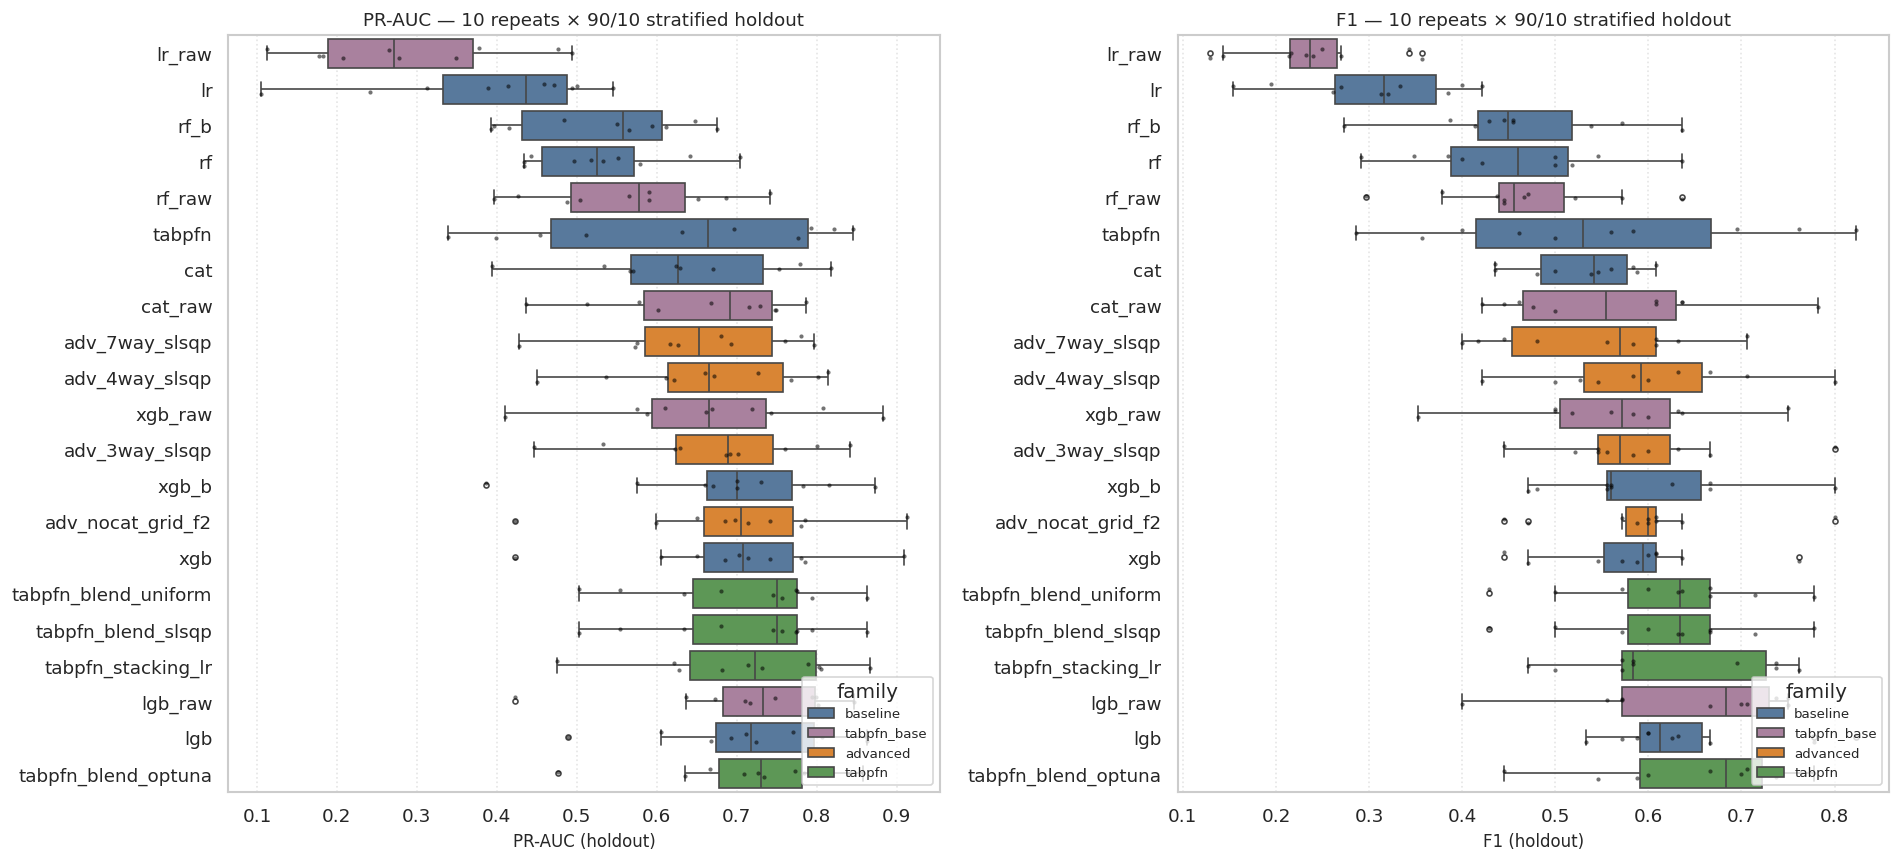

Saved figure: /kaggle/working/modeling_results/results_repeated_holdout_boxplots.png
Manifest: {'protocol': 'repeated_stratified_holdout', 'n_repeats': 10, 'holdout_frac': 0.1, 'inner_oof_splits': 5, 'inner_oof_splits_tabpfn': 5, 'random_state': 42, 'tabpfn_ran': True, 'optuna_ran': True, 'top_model': 'tabpfn_blend_optuna', 'top_pr_auc_mean': 0.7206, 'top_pr_auc_ci95': [0.5127, 0.8544]}


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

_repeat_palette = {
    "baseline": "#4C78A8",
    "advanced": "#F58518",
    "tabpfn": "#54A24B",
    "scaled": "#B07AA1",
}

pr_df = repeat_df[repeat_df["threshold_beta"] == THRESHOLD_BETAS[0]].copy()   # PR-AUC/ROC-AUC are threshold-invariant → dedupe
order = (pr_df.groupby("model")["pr_auc"].mean().sort_values(ascending=True).index.tolist())

def _boxpanel(ax, data, metric, title, xlabel):
    sns.boxplot(
        data=data, y="model", x=metric, order=order,
        hue="family", palette=_repeat_palette, dodge=False, ax=ax,
        fliersize=3, linewidth=1,
    )
    sns.stripplot(
        data=data, y="model", x=metric, order=order,
        color="black", size=2.5, alpha=0.55, ax=ax, jitter=0.15,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.legend(loc="lower right", fontsize=8, title="family")
    ax.grid(axis="x", linestyle=":", alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(22, max(6, 0.4 * len(order))))
split_tag = f"{N_REPEATS} repeats × {int((1-HOLDOUT_FRAC)*100)}/{int(HOLDOUT_FRAC*100)} stratified holdout"

_boxpanel(axes[0], pr_df, "pr_auc", f"PR-AUC — {split_tag}", "PR-AUC (holdout)")

f1_df = repeat_df[repeat_df["threshold_beta"] == 1.0]
_boxpanel(axes[1], f1_df, "f1", f"F1 @ max-F1 threshold — {split_tag}", "F1 (holdout)")

f2_df = repeat_df[repeat_df["threshold_beta"] == 2.0]
_boxpanel(axes[2], f2_df, "f2", f"F2 @ max-F2 threshold — {split_tag}", "F2 (holdout)")

plt.tight_layout()
fig_path = RESULT_DIR / "results_repeated_holdout_boxplots.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

top_row = leaderboard.iloc[0]
repeated_manifest = {
    "protocol": "repeated_stratified_holdout",
    "use_scaled_ohe": bool(USE_SCALED_OHE),
    "n_repeats": N_REPEATS,
    "holdout_frac": HOLDOUT_FRAC,
    "inner_oof_splits": INNER_OOF_SPLITS,
    "threshold_betas": list(THRESHOLD_BETAS),
    "random_state": RANDOM_STATE,
    "tabpfn_ran": bool(TABPFN_AVAILABLE),
    "optuna_ran": bool(OPTUNA_AVAILABLE),
    "top_model": top_row["model"],
    "top_threshold_beta": float(top_row["threshold_beta"]),
    "top_pr_auc_mean": float(top_row["pr_auc_mean"]),
    "top_pr_auc_ci95": [float(top_row["pr_auc_p2p5"]),
                        float(top_row["pr_auc_p97p5"])],
}
with open(RESULT_DIR / "results_repeated_holdout_manifest.json", "w", encoding="utf-8") as f:
    json.dump(repeated_manifest, f, indent=2)
print("Manifest:", repeated_manifest)